# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [6]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [20]:


# mostrar las primeras 5 filas de plans
display(plans.head(5))



,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [19]:


# mostrar las primeras 5 filas de users
display(users.head(5))



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [18]:

# mostrar las primeras 5 filas de usage
display(usage.head(5))


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [21]:



# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)




plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [23]:

# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [24]:

# inspección de users con .info()
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [22]:


# inspección de usage con .info()
usage.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [28]:



# cantidad de nulos para users
#print(# Cantidad de valores nulos)
#print(# Proporción de valores nulos)
print(users.isna().sum().sort_values(ascending=False))
print((users.isna().mean() * 100).sort_values(ascending=False).round(2))



churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64
churn_date    88.35
city          11.72
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
reg_date       0.00
plan           0.00
dtype: float64


In [29]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values(ascending=False))
print((usage.isna().mean() * 100).sort_values(ascending=False).round(2))

duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64
duration    55.19
length      44.74
date         0.12
id           0.00
user_id      0.00
type         0.00
dtype: float64





✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Para users
- city (469 nulos, 11.7%)
  
La columna city tiene un porcentaje moderado de nulos (≈11.7%).
Acción recomendada: Investigar e imputar (por ejemplo “Unknown/No especificado” o imputación por ciudad más frecuente por plan/segmento) o dejar nulos si no es crítica; justificación: está en el rango 5–30% y podría afectar análisis por región si se ignora.

churn_date (3534 nulos, 88.35%)

La columna churn_date tiene un porcentaje muy alto de nulos (≈88.35%).
Acción recomendada: No imputar fechas; mantenerla como nula y crear una variable is_churn (1 si tiene fecha, 0 si es nulo) o excluir churn_date si no se usará; justificación: >80–90% de nulos sugiere que la fecha solo existe para pocos casos (probablemente usuarios que sí churnearon) y no conviene imputarla.

para usage
uration (22,076 nulos, 55.19%)

Más de la mitad de los registros no tienen duration.
Acción recomendada: Investigar el origen (si depende de type o de un periodo) y no imputar a ciegas; si es necesaria para análisis, imputar con una regla por type (mediana por tipo) o limitar el análisis a filas con duration; justificación: es un porcentaje muy alto (>>30%) y una imputación simple sesgaría resultados.

length (17,896 nulos, 44.74%)

Casi la mitad de los registros no tienen length.
Acción recomendada: Investigar relación con type (p.ej., si length solo aplica a ciertos eventos) y tratarla como “no aplica” cuando corresponda, o imputar por grupo si aplica; justificación: porcentaje alto (>>30%) sugiere que el campo puede ser opcional/no aplicable según el tipo de uso.
date (50 nulos, 0.12%)

Muy pocos registros carecen de fecha.
Acción recomendada: Eliminar esas filas (o imputar si tienes una fuente confiable), porque son muy pocas; justificación: <5% y la fecha suele ser clave para análisis temporal, así que es un caso simple.





### 

2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.




In [30]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- Se observa que user_id tiene 4000 registros y un rango 10000–13999, consistente con un identificador (sin valores negativos ni fuera de rango aparente), por lo que no presenta sentinels evidentes.
- La columna `age` ...
- Se observa un valor mínimo de -999, lo cual es un sentinel (edad inválida) y además explica la desviación estándar muy alta; se recomienda reemplazar -999 por NaN para tratarlo como valor faltante antes del análisis. 

In [31]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
  id va de 1 a 40000 (parece identificador consecutivo) y user_id va de 10000 a 13999, consistente con el rango observado en users, por lo que no se ven sentinels evidentes; recomendación: validar que id sea único y que user_id exista en users (integridad referencial).
- Las columnas ...
  Se observan mínimos en 0 para ambas y máximos altos (duration hasta 120 y length hasta 1490), lo que puede ser válido o indicar outliers/sentinels según el significado y el type; recomendación: revisar por categoría type (y/o percentiles) para decidir si los ceros son “no aplica” y si los máximos son casos reales o errores, y tratar outliers si afectan el análisis.

In [2]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print(users[col].value_counts(dropna=False).head(20))






--- city ---


NameError: name 'users' is not defined

- La columna `city` ...
  Se observan 469 nulos y un valor “?” (96 registros) que actúa como sentinel / valor inválido; recomendación: reemplazar "?" por NaN y luego imputar como “Unknown/No especificado” o dejar nulos según el análisis; justificación: "?" no es una ciudad real y distorsiona conteos/segmentación por ciudad.
- La columna `plan` ...
  Solo aparecen dos categorías (Basico y Premium) y no hay nulos, lo cual es consistente; recomendación: mantenerla y solo estandarizar formato (por ejemplo, tildes/mayúsculas) si luego se combina con otros datasets; justificación: no hay valores inesperados, por lo que no se detectan sentinels.

In [3]:



# explorar columna categórica de usage
usage['type'] # completa el código
usage['type'].value_counts(dropna=False)




NameError: name 'usage' is not defined

- La columna `type` ...
  solo contiene dos categorías (text y call) y no presenta nulos ni valores inesperados; recomendación: mantenerla y validar que el dataset efectivamente solo contempla esos tipos (y estandarizar minúsculas si se combina con otras fuentes); justificación: al no haber categorías extrañas, no se detectan sentinels en esta variable.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  Los únicos valores tipo sentinel encontrados están en churn_date, donde los NaN indican que el usuario no ha cancelado el servicio. En city, los NaN parecen ser valores faltantes reales.
  
- ¿Qué acción tomarías?
La acción recomendada es conservar churn_date como está o convertirlo en una variable binaria, y tratar city según el objetivo del análisis, por ejemplo reemplazando los faltantes por "unknown"

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [10]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [11]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [12]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
se identificaron años 2022, 2023, 2024 y 2026. Como el dataset solo contiene información hasta 2024, los 40 registros con año 2026 se consideran fechas fuera de rango y probablemente corresponden a errores de captura. La acción recomendada es revisarlos y, si no es posible corregirlos, reemplazarlos por NaT o excluirlos del análisis.

In [13]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
todos los años válidos corresponden a 2024, por lo que no se detectaron fechas futuras ni imposibles. No obstante, existen 50 valores nulos (NaT) generados durante la conversión, lo que indica fechas inválidas o mal formateadas. En este caso, se recomienda revisar esos registros y, si no pueden corregirse, mantenerlos como faltantes o eliminarlos en análisis donde la fecha sea indispensable.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [18]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [19]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna(), margins=True))

duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [25]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna(), margins=True))

length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

El análisis entre type y los nulos de duration y length muestra que los valores faltantes dependen del tipo de uso registrado. En duration, los valores están presentes casi exclusivamente en registros call, mientras que en text aparecen como nulos. En length, ocurre lo contrario: los valores están presentes en registros text y son nulos en call. Esto nos indica que los nulos no son errores aleatorios, sino que responden a la lógica del dataset, ya que cada variable solo aplica a un tipo específico de evento. Por esta razón, se decidió mantener estos valores como nulos y no imputarlos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()


# observar resultado
usage_agg.head(3)



,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())


               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [30]:
# Distribución porcentual del tipo de plan
print((user_profile['plan'].value_counts(normalize=True) * 100).round(2))

Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

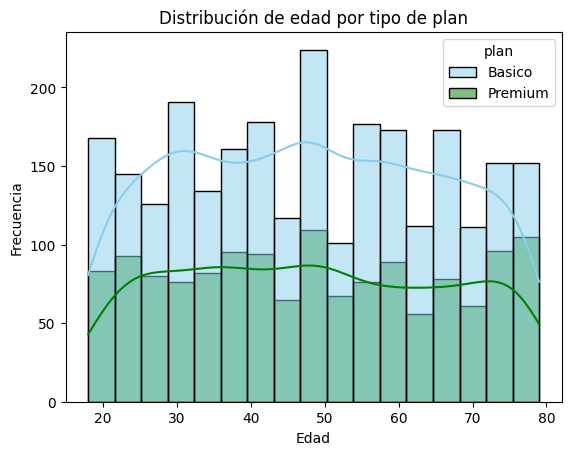

In [31]:
# Histograma para visualizar la edad (age)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=user_profile, x='age', hue='plan', kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
No se observa un patrón claro entre la edad y el tipo de plan, ya que ambas distribuciones son similares. La variable age presenta una distribución relativamente simétrica o cercana a una forma equilibrada, sin sesgos extremos.
- Distribución ...

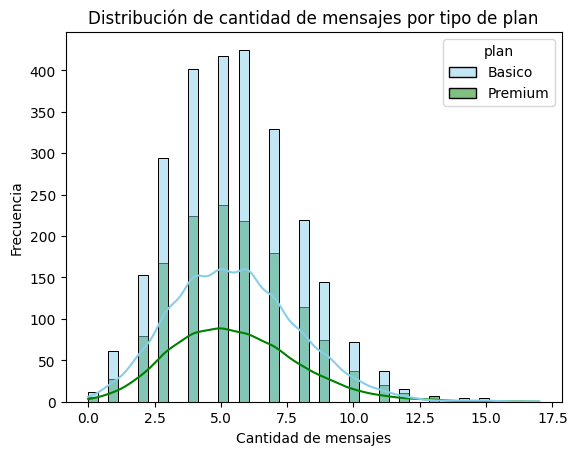

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La cantidad de mensajes presenta una distribución sesgada a la derecha, ya que la mayoría de usuarios envía pocos o medianos mensajes y unos pocos concentran valores altos. Dependiendo del gráfico, puede observarse si el plan Premium tiene mayor proporción de usuarios con alto envío de mensajes.
- ....

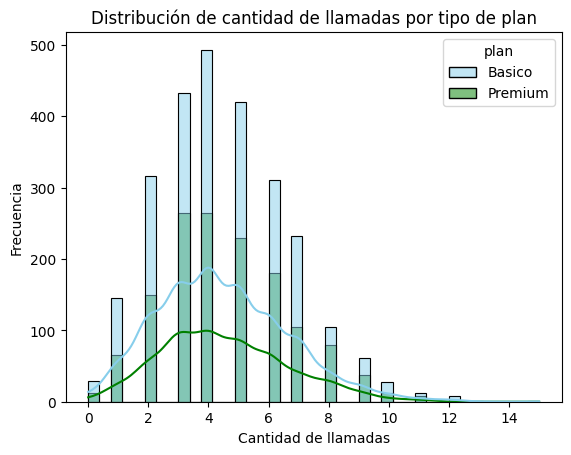

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: La variable cant_llamadas muestra una distribución sesgada a la derecha. La mayoría de usuarios realiza una cantidad moderada de llamadas, mientras que pocos usuarios presentan valores muy altos. No necesariamente se observa un patrón fuerte entre planes, salvo que el histograma muestre una diferencia clara.


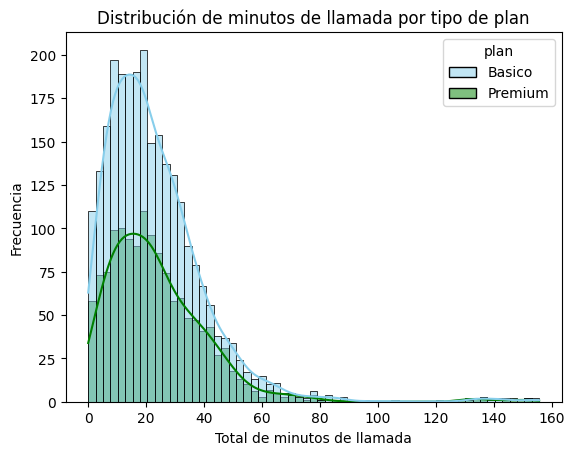

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', kde=True, palette=['skyblue', 'green'])
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La variable cant_minutos_llamada presenta una distribución sesgada a la derecha, con algunos usuarios acumulando muchos más minutos que el resto. Si uno de los planes muestra mayor concentración en valores altos, esto puede indicar un uso más intensivo de llamadas en ese grupo


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [ ]:

# Calcular límites con el método IQR
columnas_limites = [...]




In [ ]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

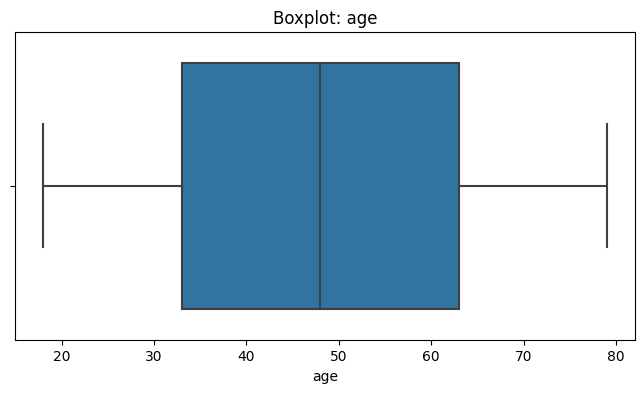

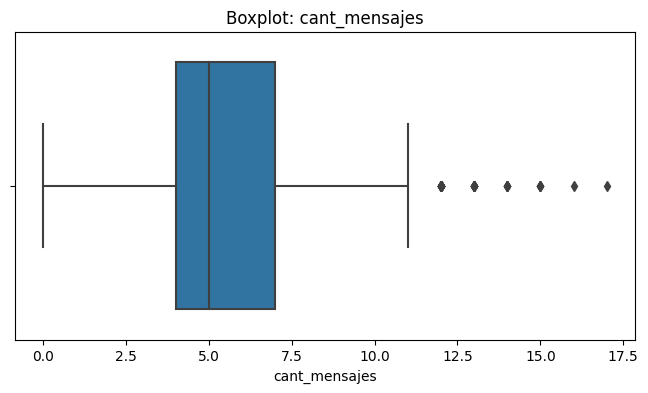

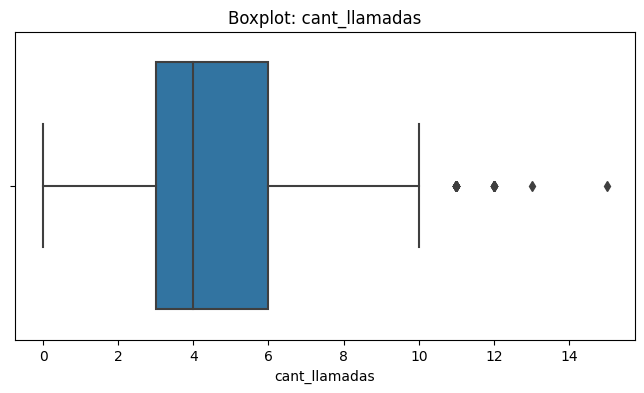

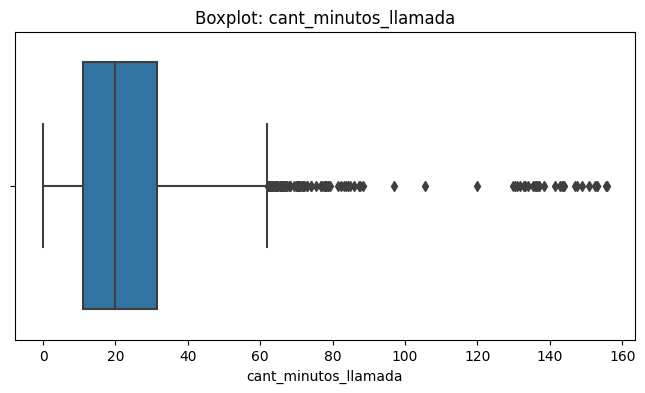

In [35]:
# Crear columna grupo_uso
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

In [36]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
import numpy as np


In [40]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor')
)

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

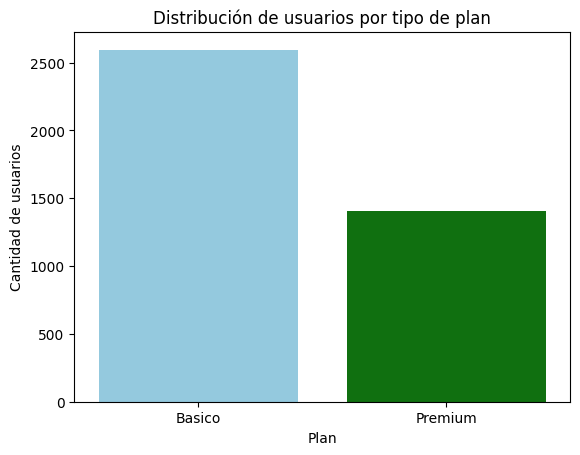

In [42]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='plan', palette=['skyblue', 'green'])
plt.title('Distribución de usuarios por tipo de plan')
plt.xlabel('Plan')
plt.ylabel('Cantidad de usuarios')
plt.show()


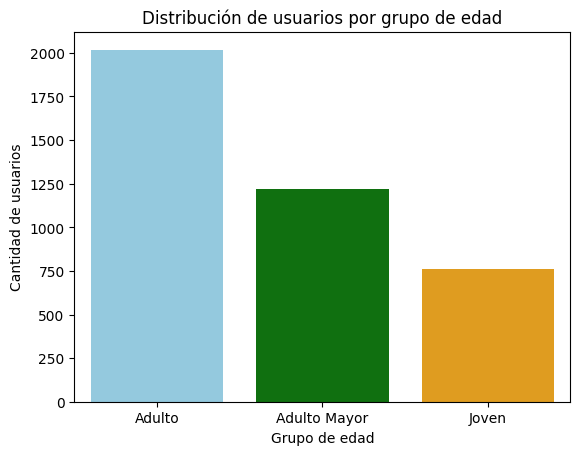

In [43]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

n la columna churn_date había 3534 valores nulos, lo que representaba el 88.35% de los registros. Sin embargo, estos nulos no se interpretaron como error, sino como una condición válida que indica usuarios activos sin fecha de cancelación.
En city se encontraron 469 valores nulos, equivalentes al 11.72% de la columna. Además, también aparecía el valor sentinel "?", que fue tratado como dato faltante.
En reg_date se detectaron 40 registros con el año 2026, lo cual es inconsistente porque el dataset solo contiene datos hasta 2024. Estos casos se consideraron fechas imposibles.
En usage['date'] hubo 50 valores que no pudieron convertirse correctamente a fecha, por lo que quedaron como nulos (NaT).
En age existía el valor sentinel -999, que representaba una edad inválida y fue reemplazado por la mediana.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron segmentos de clientes principalmente por edad y por nivel de uso.
Segmentación por edad
Se clasificó a los usuarios en tres grupos:
Joven: menores de 30 años
Adulto: entre 30 y 59 años
Adulto Mayor: 60 años o más
Esta segmentación permite analizar diferencias en comportamiento y potencial de consumo.
Segmentación por uso
A partir de la tabla agregada por usuario, se construyeron métricas de comportamiento histórico:
cantidad de mensajes
cantidad de llamadas
minutos totales de llamada
Con estas variables se observó que existen usuarios con consumo bajo, medio y alto. Además, los histogramas por plan permiten identificar si ciertos planes concentran usuarios con mayor uso de mensajes o llamadas.
En términos generales:
algunos usuarios muestran un uso intensivo de mensajería
otros concentran mayor consumo en llamadas y minutos
no todos los segmentos presentan el mismo patrón de consumo, lo que sugiere oportunidades de personalización comercial

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los segmentos más valiosos parecen ser aquellos usuarios con alto nivel de uso, especialmente los que presentan:
mayor cantidad de llamadas
mayor cantidad de mensajes
mayor acumulación de minutos de llamada
Estos clientes son valiosos porque:
generan mayor consumo del servicio
tienen más probabilidad de aprovechar planes premium o paquetes adicionales
pueden responder mejor a ofertas segmentadas según su patrón de uso

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se identificaron outliers principalmente en:
cant_mensajes
cant_llamadas
cant_minutos_llamada
Estos valores extremos se concentran en el extremo superior y no parecen corresponder a errores de captura, sino a usuarios con un uso intensivo real del servicio.

Los outliers son relevantes porque muestran que existe un grupo de clientes con necesidades de consumo significativamente mayores al promedio. Esto puede implicar:
oportunidad para planes de alto consumo
riesgo de saturación o sobreuso en planes actuales
necesidad de ofertas diferenciadas para heavy users
posibilidad de diseñar beneficios premium o paquetes adicionales específicos
En lugar de eliminar estos casos, conviene analizarlos como un segmento estratégico

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
se pueden proponer varias acciones:
a) Diseñar planes segmentados por patrón de uso
Crear o ajustar planes según comportamiento real:
planes orientados a usuarios con alta mensajería
planes para usuarios con alto consumo de llamadas
planes balanceados para usuarios con consumo mixto
b) Crear ofertas para heavy users
Los usuarios con valores extremos en mensajes o minutos podrían beneficiarse de:
paquetes premium
beneficios adicionales
límites más amplios o consumo preferencial
c) Personalizar campañas por grupo de edad
La segmentación por edad puede ayudar a adaptar la propuesta de valor:
usuarios jóvenes: planes con mayor foco en mensajería
adultos: planes balanceados
adultos mayores: planes simples y claros, posiblemente con énfasis en llamadas
d) Revisar si el plan actual refleja el uso real
Si se detecta que ciertos usuarios del plan básico tienen un uso intensivo, podría existir una oportunidad de:
migrarlos a planes superiores
ofrecer upgrades personalizados
mejorar la rentabilidad por usuario

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se identificaron valores nulos en columnas clave como churn_date y city. En churn_date, los 3534 nulos (88.35%) corresponden a usuarios activos, por lo que no representan un error, sino una condición válida del negocio.
En city se encontraron 469 nulos (11.72%) y valores sentinel como "?", que fueron tratados como datos faltantes. Además, en reg_date se detectaron 40 fechas fuera de rango (año 2026) y en usage['date'] hubo 50 fechas inválidas que no pudieron convertirse correctamente.


🔍 **Segmentos por Edad**
Los usuarios fueron clasificados en tres grupos: Joven (age < 30), Adulto (age < 60) y Adulto Mayor (60 o más), lo que permitió organizar mejor el análisis del perfil de clientes.
Esta segmentación ayuda a identificar diferencias potenciales en comportamiento y consumo, y sirve como base para diseñar ofertas más personalizadas según etapa de vida.


📊 **Segmentos por Nivel de Uso**

A partir de la tabla agregada por usuario, se construyeron métricas de uso como cantidad de mensajes, cantidad de llamadas y minutos totales de llamada, lo que permitió distinguir usuarios de consumo bajo, medio y alto.
También se detectaron outliers en cant_mensajes, cant_llamadas y cant_minutos_llamada, lo que sugiere la existencia de usuarios intensivos cuyo comportamiento puede representar oportunidades comerciales relevantes.

➡️ Esto sugiere que ...
ConnectaTel no tiene una base homogénea de clientes: existen diferencias tanto por edad como por intensidad de uso, lo que indica que una oferta única puede no ser la más eficiente.
Los usuarios con consumo extremo no deben verse como anomalías a eliminar, sino como segmentos valiosos que podrían beneficiarse de planes específicos, upgrades o estrategias de retención.

💡 **Recomendaciones**
-Ajustar la oferta comercial con planes más segmentados según el patrón de uso: por ejemplo, planes orientados a usuarios con alta mensajería, alta frecuencia de llamadas o alto consumo total.
Diseñar campañas diferenciadas por grupo etario y por nivel de uso, aprovechando la segmentación para mejorar la personalización, la retención y las oportunidades de upselling.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`